In [1]:
# Cell 1: Install and import dependencies
# Colab-safe: auto-resolve project root and bootstrap scripts only when missing.

import json
import os
import shutil
import subprocess
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Dict, Tuple

def _run_pip_install(packages):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
        return True
    except Exception as e:
        print(f"[Warning] pip install failed: {e}")
        return False

def _best_effort_remove_legacy_gym():
    # Old gym prints noisy warnings and may conflict with Gymnasium stacks.
    try:
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "gym"],
                       check=False, capture_output=True, text=True)
    except Exception:
        pass

def _repair_numpy_if_needed():
    try:
        import numpy as np  # noqa: F401
        return True
    except Exception as e:
        print(f"[Warning] NumPy import failed, attempting repair: {e}")

    repair_cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--force-reinstall",
        "--no-cache-dir",
        "numpy==2.2.6",
    ]
    try:
        subprocess.check_call(repair_cmd)
        import numpy as np  # noqa: F401
        print("[Info] NumPy repair succeeded.")
        return True
    except Exception as repair_err:
        print(f"[Error] NumPy repair failed: {repair_err}")
        print("Please restart the kernel, then run Cell 1 again.")
        return False

# Core RL stack
_run_pip_install([
    "stable-baselines3[extra]>=2.0.0",
    "gymnasium[atari,accept-rom-license]>=0.29.0",
    "ale-py",
    "shimmy",
    "tensorboard",
    "pandas",
    "matplotlib",
])
_best_effort_remove_legacy_gym()

if not _repair_numpy_if_needed():
    raise RuntimeError("NumPy is still broken after repair attempt. Restart kernel and rerun Cell 1.")

# Suppress noisy deprecation warnings in notebooks
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import pandas as pd
import gymnasium as gym
import ale_py  # noqa: F401
from stable_baselines3 import DQN

# Ensure matplotlib renders in notebook output.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 140

ENV_ID = "ALE/Boxing-v5"
MEMBER = "Raissa"
TRAIN_LOG_PROGRESS_EVERY = 5_000

# Resolve project root robustly for VS Code + Kaggle + Colab
IS_KAGGLE = Path("/kaggle").exists()
root_candidates = [
    Path("/kaggle/working/boxing_dqn_agent"),
    Path("/kaggle/input/boxing_dqn_agent"),
    Path("/content/boxing_dqn_agent"),
    Path("/content/drive/MyDrive/boxing_dqn_agent"),
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
]

PROJECT_ROOT = None
for candidate in root_candidates:
    has_scripts = (candidate / "scripts" / "train.py").exists() and (candidate / "scripts" / "play.py").exists()
    if not has_scripts:
        continue

    # Avoid locking onto bare /content unless it looks like the actual repository.
    is_bare_content = candidate.resolve() == Path("/content").resolve()
    has_repo_markers = (candidate / "README.md").exists() and (candidate / "requirements.txt").exists()
    if is_bare_content and not has_repo_markers:
        continue

    PROJECT_ROOT = candidate
    break

if PROJECT_ROOT is None:
    # Fallback: detect project root by repository markers even if scripts/ does not exist yet.
    marker_candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    content_root = Path("/content")
    if content_root.exists():
        marker_candidates.extend([p for p in content_root.glob("**/boxing_dqn_agent") if p.is_dir()])

    for candidate in marker_candidates:
        has_markers = (candidate / "README.md").exists() and (candidate / "requirements.txt").exists()
        if has_markers:
            PROJECT_ROOT = candidate
            break

if PROJECT_ROOT is None:
    # Fallback upward search
    probe = Path.cwd().resolve()
    while probe != probe.parent:
        if (probe / "scripts" / "train.py").exists() and (probe / "scripts" / "play.py").exists():
            PROJECT_ROOT = probe
            break
        probe = probe.parent

if PROJECT_ROOT is None:
    # Last resort in Colab: search under /content
    content_root = Path("/content")
    if content_root.exists():
        matches = list(content_root.rglob("scripts/train.py"))
        if matches:
            PROJECT_ROOT = matches[0].parent.parent.resolve()

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd().resolve()

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
SCRIPTS_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_SCRIPT = SCRIPTS_DIR / "train.py"
PLAY_SCRIPT = SCRIPTS_DIR / "play.py"

# Bootstrap scripts only if missing, so notebook never hard-fails on path mismatch.
TRAIN_BOOTSTRAP = textwrap.dedent(
    """
    #!/usr/bin/env python
    # AUTO-GENERATED BY NOTEBOOK BOOTSTRAP
    import argparse, json, time
    from pathlib import Path

    import ale_py  # noqa: F401
    import gymnasium as gym
    from stable_baselines3 import DQN
    from stable_baselines3.common.env_util import make_atari_env
    from stable_baselines3.common.evaluation import evaluate_policy
    from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

    def make_env(policy, env_id, seed):
        if policy == "CnnPolicy":
            env = make_atari_env(env_id, n_envs=1, seed=seed)
            env = VecFrameStack(env, n_stack=4)
            return env

        # RAM fallback for MLP. Try common Gymnasium Atari IDs in order.
        base = env_id.split("/")[-1]
        game = base.split("-")[0]
        ram_ids = [
            f"{game}-ram-v5" ,
            f"ALE/{game}-v5" ,
            f"ALE/{game}" ,
        ]
        last_err = None

        def _make_ram_env(rid):
            try:
                return gym.make(rid, obs_type="ram")
            except TypeError:
                # Some env specs may ignore obs_type and already be RAM variants.
                return gym.make(rid)

        for rid in ram_ids:
            try:
                return DummyVecEnv([lambda rid=rid: _make_ram_env(rid)])
            except Exception as e:
                last_err = e

        raise RuntimeError(f"Cannot create MLP env. Tried {ram_ids}. Last error: {last_err}")

    def parse_args():
        p = argparse.ArgumentParser()
        p.add_argument("--member", required=True)
        p.add_argument("--experiment", required=True)
        p.add_argument("--env-id", default="ALE/Boxing-v5")
        p.add_argument("--policy", choices=["CnnPolicy", "MlpPolicy"], default="CnnPolicy")
        p.add_argument("--total-timesteps", type=int, default=100000)
        p.add_argument("--seed", type=int, default=42)
        p.add_argument("--device", default="auto")
        p.add_argument("--learning-rate", type=float, default=1e-4)
        p.add_argument("--gamma", type=float, default=0.99)
        p.add_argument("--batch-size", type=int, default=32)
        p.add_argument("--buffer-size", type=int, default=50000)
        p.add_argument("--learning-starts", type=int, default=2000)
        p.add_argument("--train-freq", type=int, default=4)
        p.add_argument("--gradient-steps", type=int, default=1)
        p.add_argument("--target-update-interval", type=int, default=10000)
        p.add_argument("--exploration-initial-eps", type=float, default=1.0)
        p.add_argument("--exploration-final-eps", type=float, default=0.05)
        p.add_argument("--exploration-fraction", type=float, default=0.1)
        p.add_argument("--eval-episodes", type=int, default=5)
        p.add_argument("--eval-freq", type=int, default=10000)
        p.add_argument("--log-progress-every", type=int, default=5000)
        return p.parse_args()

    def main():
        args = parse_args()
        base = Path("results") / args.member
        (base / "models").mkdir(parents=True, exist_ok=True)
        (base / "logs").mkdir(parents=True, exist_ok=True)
        (base / args.experiment).mkdir(parents=True, exist_ok=True)

        train_env = make_env(args.policy, args.env_id, args.seed)
        eval_env = make_env(args.policy, args.env_id, args.seed + 100)

        model = DQN(
            args.policy,
            train_env,
            learning_rate=args.learning_rate,
            gamma=args.gamma,
            batch_size=args.batch_size,
            buffer_size=args.buffer_size,
            learning_starts=args.learning_starts,
            train_freq=args.train_freq,
            gradient_steps=args.gradient_steps,
            target_update_interval=args.target_update_interval,
            exploration_initial_eps=args.exploration_initial_eps,
            exploration_final_eps=args.exploration_final_eps,
            exploration_fraction=args.exploration_fraction,
            seed=args.seed,
            device=args.device,
            verbose=1,
        )

        t0 = time.time()
        model.learn(total_timesteps=args.total_timesteps, progress_bar=False)
        train_minutes = (time.time() - t0) / 60.0

        model_path = base / "models" / f"{args.experiment}.zip"
        model.save(str(model_path.with_suffix("")))

        mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=args.eval_episodes, deterministic=True)

        out = {
            "member": args.member,
            "experiment": args.experiment,
            "policy": args.policy,
            "env_id": args.env_id,
            "mean_reward": float(mean_r),
            "std_reward": float(std_r),
            "train_minutes": float(train_minutes),
            "model_path": str(model_path),
            "total_timesteps": int(args.total_timesteps),
        }
        out_path = base / args.experiment / f"{args.experiment}_eval.json"
        out_path.write_text(json.dumps(out, indent=2), encoding="utf-8")
        print(f"[DONE] {args.experiment} mean={mean_r:.2f} +/- {std_r:.2f}")

        train_env.close()
        eval_env.close()

    if __name__ == "__main__":
        main()
    """
).strip() + "\n"

PLAY_BOOTSTRAP = textwrap.dedent(
    """
    #!/usr/bin/env python
    # AUTO-GENERATED BY NOTEBOOK BOOTSTRAP
    import argparse
    from pathlib import Path

    import ale_py  # noqa: F401
    import gymnasium as gym
    from stable_baselines3 import DQN
    from stable_baselines3.common.env_util import make_atari_env
    from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack, VecVideoRecorder

    def parse_args():
        p = argparse.ArgumentParser()
        p.add_argument("--model-path", required=True)
        p.add_argument("--env-id", default="ALE/Boxing-v5")
        p.add_argument("--policy", choices=["CnnPolicy", "MlpPolicy"], default="CnnPolicy")
        p.add_argument("--episodes", type=int, default=1)
        p.add_argument("--seed", type=int, default=42)
        p.add_argument("--max-steps", type=int, default=2000)
        p.add_argument("--record-video", action="store_true")
        p.add_argument("--video-dir", default="results/play_videos")
        p.add_argument("--video-prefix", default="dqn_play")
        return p.parse_args()

    def make_env(policy, env_id, seed):
        if policy == "CnnPolicy":
            env = make_atari_env(env_id, n_envs=1, seed=seed, env_kwargs={"render_mode": "rgb_array"})
            return VecFrameStack(env, n_stack=4)

        base = env_id.split("/")[-1]
        game = base.split("-")[0]
        ram_ids = [
            f"{game}-ram-v5" ,
            f"ALE/{game}-v5" ,
            f"ALE/{game}" ,
        ]
        last_err = None

        def _make_ram_env(rid):
            try:
                return gym.make(rid, obs_type="ram")
            except TypeError:
                return gym.make(rid)

        for rid in ram_ids:
            try:
                return DummyVecEnv([lambda rid=rid: _make_ram_env(rid)])
            except Exception as e:
                last_err = e

        raise RuntimeError(f"Cannot create playback env. Tried {ram_ids}. Last error: {last_err}")

    def main():
        args = parse_args()
        model_path = Path(args.model_path)
        if not model_path.exists():
            raise FileNotFoundError(f"Model not found: {model_path}")

        env = make_env(args.policy, args.env_id, args.seed)
        if args.record_video:
            Path(args.video_dir).mkdir(parents=True, exist_ok=True)
            env = VecVideoRecorder(
                env,
                video_folder=args.video_dir,
                record_video_trigger=lambda step: step == 0,
                video_length=args.max_steps,
                name_prefix=args.video_prefix,
            )

        model = DQN.load(str(model_path))
        obs = env.reset()
        done = [False]
        steps = 0
        ep_reward = 0.0
        while not done[0] and steps < args.max_steps:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _ = env.step(action)
            ep_reward += float(reward[0])
            steps += 1

        print(f"Episode reward: {ep_reward:.2f}")
        env.close()

    if __name__ == "__main__":
        main()
    """
).strip() + "\n"

def _maybe_refresh_bootstrap_script(path: Path, content: str, kind: str):
    if not path.exists():
        path.write_text(content, encoding="utf-8")
        print(f"[Info] Bootstrapped missing {kind} script: {path}")
        return

    current = path.read_text(encoding="utf-8", errors="ignore")
    is_bootstrap = "AUTO-GENERATED BY NOTEBOOK BOOTSTRAP" in current
    has_legacy_mlp_bug = "ALE/Boxing-ram-v5" in current and "Cannot create MLP env" in current
    if is_bootstrap or has_legacy_mlp_bug:
        path.write_text(content, encoding="utf-8")
        print(f"[Info] Refreshed {kind} script with latest bootstrap fixes: {path}")

_maybe_refresh_bootstrap_script(TRAIN_SCRIPT, TRAIN_BOOTSTRAP, "train")
_maybe_refresh_bootstrap_script(PLAY_SCRIPT, PLAY_BOOTSTRAP, "play")

BASE_DIR = PROJECT_ROOT / "results" / MEMBER
MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"
TABLE_DIR = BASE_DIR / "tables"
VIDEO_DIR = BASE_DIR / "videos"
for p in [MODEL_DIR, LOG_DIR, TABLE_DIR, VIDEO_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Kaggle cannot mount Google Drive directly in most runtimes. Use DRIVE_RESULTS_DIR
# if a mounted/synced drive path is available, otherwise default to Kaggle working dir.
DEFAULT_BACKUP_ROOT = Path("/kaggle/working/drive_backup") if IS_KAGGLE else Path("/content/drive/MyDrive")
DRIVE_RESULTS_DIR = Path(os.environ.get("DRIVE_RESULTS_DIR", str(DEFAULT_BACKUP_ROOT / "boxing_dqn_agent")))
DRIVE_MEMBER_DIR = DRIVE_RESULTS_DIR / "results" / MEMBER
DRIVE_MEMBER_DIR.mkdir(parents=True, exist_ok=True)

def sync_results_to_drive(reason: str = "manual"):
    if not BASE_DIR.exists():
        print("[SYNC] No local results directory to sync yet.")
        return
    shutil.copytree(BASE_DIR, DRIVE_MEMBER_DIR, dirs_exist_ok=True)
    print(f"[SYNC] Synced ({reason}) -> {DRIVE_MEMBER_DIR}")

print(f"Project root      : {PROJECT_ROOT}")
print(f"Environment       : {ENV_ID}")
print(f"Member            : {MEMBER}")
print(f"Runtime           : {'Kaggle' if IS_KAGGLE else 'Local/Other'}")
print(f"Train script      : {TRAIN_SCRIPT}")
print(f"Play script       : {PLAY_SCRIPT}")
print(f"Backup target dir : {DRIVE_MEMBER_DIR}")

# Quick environment check
check_env = gym.make(ENV_ID)
check_env.close()
print("Boxing environment is available.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 3.7 MB/s eta 0:00:00


2026-03-21 11:16:31.628502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774091791.815543      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774091791.870658      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774091792.315003      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774091792.315047      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774091792.315049      55 computation_placer.cc:177] computation placer alr

[Info] Bootstrapped missing train script: /kaggle/working/scripts/train.py
[Info] Bootstrapped missing play script: /kaggle/working/scripts/play.py
Project root      : /kaggle/working
Environment       : ALE/Boxing-v5
Member            : Raissa
Runtime           : Kaggle
Train script      : /kaggle/working/scripts/train.py
Play script       : /kaggle/working/scripts/play.py
Backup target dir : /kaggle/working/drive_backup/boxing_dqn_agent/results/Raissa
Boxing environment is available.


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


## 1. Environment Exploration

Environment       : ALE/Boxing-v5
Action space      : Discrete(18)
Observation space : Box(0, 255, (210, 160, 3), uint8)
Reward range      : approximately [-100, +100]

Available actions (18):
 0: NOOP
 1: FIRE
 2: UP
 3: RIGHT
 4: LEFT
 5: DOWN
 6: UPRIGHT
 7: UPLEFT
 8: DOWNRIGHT
 9: DOWNLEFT
10: UPFIRE
11: RIGHTFIRE
12: LEFTFIRE
13: DOWNFIRE
14: UPRIGHTFIRE
15: UPLEFTFIRE
16: DOWNRIGHTFIRE
17: DOWNLEFTFIRE


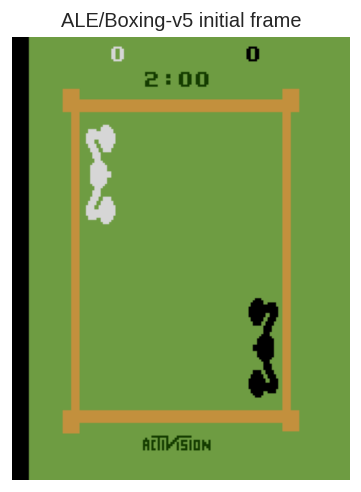

Environment exploration complete.


In [2]:
# Environment exploration for ALE/Boxing-v5
if "gym" not in globals():
    import gymnasium as gym
if "ENV_ID" not in globals():
    ENV_ID = "ALE/Boxing-v5"
env = gym.make(ENV_ID, render_mode="rgb_array")

print("=" * 60)
print(f"Environment       : {ENV_ID}")
print(f"Action space      : {env.action_space}")
print(f"Observation space : {env.observation_space}")
print("Reward range      : approximately [-100, +100]")
print("=" * 60)

meanings = env.unwrapped.get_action_meanings()
print(f"\nAvailable actions ({len(meanings)}):")
for i, m in enumerate(meanings):
    print(f"{i:>2}: {m}")

obs, _ = env.reset(seed=42)
fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.imshow(obs)
ax.set_title("ALE/Boxing-v5 initial frame")
ax.axis("off")
plt.tight_layout()
plt.show()
plt.close(fig)

env.close()
print("Environment exploration complete.")

In [3]:
# Cell 2: Helper to run scripts/train.py for one experiment

def run_train_script(
    experiment_name: str,
    policy: str,
    hyperparams: Dict,
    total_timesteps: int = 50_000,
    seed: int = 42,
    eval_episodes: int = 5,
    device: str = "auto",
) -> Tuple[Dict, bool]:
    if not TRAIN_SCRIPT.exists():
        raise FileNotFoundError(f"train.py not found: {TRAIN_SCRIPT}")

    cmd = [
        sys.executable,
        str(TRAIN_SCRIPT),
        "--member", MEMBER,
        "--experiment", experiment_name,
        "--env-id", ENV_ID,
        "--policy", policy,
        "--total-timesteps", str(total_timesteps),
        "--seed", str(seed),
        "--device", device,
        "--learning-rate", str(hyperparams["learning_rate"]),
        "--gamma", str(hyperparams["gamma"]),
        "--batch-size", str(hyperparams["batch_size"]),
        "--buffer-size", str(hyperparams["buffer_size"]),
        "--learning-starts", str(hyperparams["learning_starts"]),
        "--train-freq", str(hyperparams["train_freq"]),
        "--gradient-steps", str(hyperparams["gradient_steps"]),
        "--target-update-interval", str(hyperparams["target_update_interval"]),
        "--exploration-initial-eps", str(hyperparams["exploration_initial_eps"]),
        "--exploration-final-eps", str(hyperparams["exploration_final_eps"]),
        "--exploration-fraction", str(hyperparams["exploration_fraction"]),
        "--eval-episodes", str(eval_episodes),
        "--log-progress-every", str(TRAIN_LOG_PROGRESS_EVERY),
    ]

    eval_json_path = BASE_DIR / experiment_name / f"{experiment_name}_eval.json"

    print("\n" + "=" * 72)
    print(f"Running {experiment_name} ({policy})")
    print("=" * 72)

    run = subprocess.run(cmd, cwd=str(PROJECT_ROOT), capture_output=True, text=True)

    if run.stdout:
        print(run.stdout[-1800:])

    if run.returncode != 0:
        err_msg = run.stderr[-1800:] if run.stderr else f"train.py failed with code {run.returncode}"
        print("[ERROR] Training failed")
        print(err_msg)
        return {}, False

    if not eval_json_path.exists():
        print(f"[ERROR] Missing eval summary: {eval_json_path}")
        return {}, False

    with open(eval_json_path, "r", encoding="utf-8") as f:
        eval_summary = json.load(f)

    metrics = {
        "name": experiment_name,
        "policy": policy,
        "mean_reward": float(eval_summary.get("mean_reward", 0.0)),
        "std_reward": float(eval_summary.get("std_reward", 0.0)),
        "train_minutes": float(eval_summary.get("train_minutes", 0.0)),
        "learning_rate": hyperparams["learning_rate"],
        "gamma": hyperparams["gamma"],
        "batch_size": hyperparams["batch_size"],
        "exploration_initial_eps": hyperparams["exploration_initial_eps"],
        "exploration_final_eps": hyperparams["exploration_final_eps"],
        "exploration_fraction": hyperparams["exploration_fraction"],
        "model_path": eval_summary.get("model_path", str(MODEL_DIR / f"{experiment_name}.zip")),
        "training_csv_path": eval_summary.get(
            "training_csv_path",
            str(LOG_DIR / f"{experiment_name}_training_metrics.csv"),
        ),
        "total_timesteps": int(eval_summary.get("total_timesteps", total_timesteps)),
        "eval_json_path": str(eval_json_path),
    }

    return metrics, True

print("Training helper ready.")

Training helper ready.


In [4]:
# Cell 3: Define 10 Boxing experiments (5 CNN + 5 MLP paired configs)
if "pd" not in globals():
    import pandas as pd
if "ENV_ID" not in globals():
    ENV_ID = "ALE/Boxing-v5"

# Each pair shares the same hyperparameters across policies to compare behavior fairly.
paired_hyperparams = [
    dict(
        tag="baseline",
        rationale="Default DQN-style baseline for Boxing",
        learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=50_000,
        learning_starts=2_000, train_freq=4, gradient_steps=1, target_update_interval=10_000,
        exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.05,
    ),
    dict(
        tag="low_lr",
        rationale="Lower learning rate for more stable updates",
        learning_rate=5e-5, gamma=0.99, batch_size=32, buffer_size=50_000,
        learning_starts=2_000, train_freq=4, gradient_steps=1, target_update_interval=10_000,
        exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.05,
    ),
    dict(
        tag="high_lr",
        rationale="Higher learning rate for faster but riskier learning",
        learning_rate=2.5e-4, gamma=0.99, batch_size=32, buffer_size=50_000,
        learning_starts=2_000, train_freq=4, gradient_steps=1, target_update_interval=10_000,
        exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.05,
    ),
    dict(
        tag="slow_eps",
        rationale="Longer exploration schedule for broader state coverage",
        learning_rate=1e-4, gamma=0.99, batch_size=32, buffer_size=50_000,
        learning_starts=2_000, train_freq=4, gradient_steps=1, target_update_interval=10_000,
        exploration_fraction=0.50, exploration_initial_eps=1.0, exploration_final_eps=0.10,
    ),
    dict(
        tag="large_batch",
        rationale="Larger batch for smoother gradient estimates",
        learning_rate=1e-4, gamma=0.99, batch_size=128, buffer_size=50_000,
        learning_starts=2_000, train_freq=4, gradient_steps=1, target_update_interval=10_000,
        exploration_fraction=0.10, exploration_initial_eps=1.0, exploration_final_eps=0.05,
    ),
]

EXPERIMENTS = []
for idx, hp_cfg in enumerate(paired_hyperparams, start=1):
    hp_values = {k: v for k, v in hp_cfg.items() if k not in {"tag", "rationale"}}

    EXPERIMENTS.append({
        "name": f"raissa_exp{2*idx-1:02d}_cnn_{hp_cfg['tag']}",
        "policy": "CnnPolicy",
        "rationale": f"CNN pair {idx}: {hp_cfg['rationale']}",
        "hp": dict(hp_values),
    })

    EXPERIMENTS.append({
        "name": f"raissa_exp{2*idx:02d}_mlp_{hp_cfg['tag']}",
        "policy": "MlpPolicy",
        "rationale": f"MLP pair {idx}: same hyperparameters as CNN pair {idx}",
        "hp": dict(hp_values),
    })

print(f"Prepared {len(EXPERIMENTS)} experiments for {ENV_ID}")
print("Split:", pd.Series([e["policy"] for e in EXPERIMENTS]).value_counts().to_dict())

exp_table = pd.DataFrame([
    {
        "name": e["name"],
        "policy": e["policy"],
        "learning_rate": e["hp"]["learning_rate"],
        "gamma": e["hp"]["gamma"],
        "batch_size": e["hp"]["batch_size"],
        "eps_start": e["hp"]["exploration_initial_eps"],
        "eps_end": e["hp"]["exploration_final_eps"],
        "eps_frac": e["hp"]["exploration_fraction"],
        "rationale": e["rationale"],
    }
    for e in EXPERIMENTS
])
display(exp_table)

Prepared 10 experiments for ALE/Boxing-v5
Split: {'CnnPolicy': 5, 'MlpPolicy': 5}


,name,policy,learning_rate,gamma,batch_size,eps_start,eps_end,eps_frac,rationale
0,raissa_exp01_cnn_baseline,CnnPolicy,0.00010,0.99,32,1.0,0.05,0.1,CNN pair 1: Default DQN-style baseline for Boxing
1,raissa_exp02_mlp_baseline,MlpPolicy,0.00010,0.99,32,1.0,0.05,0.1,MLP pair 1: same hyperparameters as CNN pair 1
2,raissa_exp03_cnn_low_lr,CnnPolicy,0.00005,0.99,32,1.0,0.05,0.1,CNN pair 2: Lower learning rate for more stabl...
3,raissa_exp04_mlp_low_lr,MlpPolicy,0.00005,0.99,32,1.0,0.05,0.1,MLP pair 2: same hyperparameters as CNN pair 2
4,raissa_exp05_cnn_high_lr,CnnPolicy,0.00025,0.99,32,1.0,0.05,0.1,CNN pair 3: Higher learning rate for faster bu...
5,raissa_exp06_mlp_high_lr,MlpPolicy,0.00025,0.99,32,1.0,0.05,0.1,MLP pair 3: same hyperparameters as CNN pair 3
6,raissa_exp07_cnn_slow_eps,CnnPolicy,0.00010,0.99,32,1.0,0.10,0.5,CNN pair 4: Longer exploration schedule for br...
7,raissa_exp08_mlp_slow_eps,MlpPolicy,0.00010,0.99,32,1.0,0.10,0.5,MLP pair 4: same hyperparameters as CNN pair 4
8,raissa_exp09_cnn_large_batch,CnnPolicy,0.00010,0.99,128,1.0,0.05,0.1,CNN pair 5: Larger batch for smoother gradient...
9,raissa_exp10_mlp_large_batch,MlpPolicy,0.00010,0.99,128,1.0,0.05,0.1,MLP pair 5: same hyperparameters as CNN pair 5


## 2. Run All Experiments Using scripts/train.py

In [5]:
# Optional quick policy comparison (same hyperparameters, different policy)
COMPARISON_TIMESTEPS = 50_000
COMPARISON_SEED = 42
COMPARISON_EVAL_EPISODES = 3

shared_hp = dict(
    learning_rate=1e-4,
    gamma=0.99,
    batch_size=32,
    buffer_size=50_000,
    learning_starts=2_000,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=10_000,
    exploration_fraction=0.10,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
 )

comparison_rows = []
for policy_name in ["CnnPolicy", "MlpPolicy"]:
    exp_name = f"raissa_policy_compare_{policy_name.lower()}"
    metrics, success = run_train_script(
        experiment_name=exp_name,
        policy=policy_name,
        hyperparams=shared_hp,
        total_timesteps=COMPARISON_TIMESTEPS,
        seed=COMPARISON_SEED,
        eval_episodes=COMPARISON_EVAL_EPISODES,
        device="auto",
    )

    if success:
        metrics["status"] = "ok"
        metrics["error"] = ""
        comparison_rows.append(metrics)
    else:
        comparison_rows.append({
            "name": exp_name,
            "policy": policy_name,
            "mean_reward": float("nan"),
            "std_reward": float("nan"),
            "train_minutes": float("nan"),
            "status": "failed",
            "error": "See training output above",
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df[["name", "policy", "status", "mean_reward", "std_reward", "train_minutes", "error"]])


Running raissa_policy_compare_cnnpolicy (CnnPolicy)
            |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0404   |
|    n_updates        | 10527    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.79e+03 |
|    ep_rew_mean      | -9.53    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 104      |
|    fps              | 161      |
|    time_elapsed     | 284      |
|    total_timesteps  | 45872    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.105    |
|    n_updates        | 10967    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.79e+03 |
|    ep_rew_mean      | -9.33    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 108      |
|    fps    

,name,policy,status,mean_reward,std_reward,train_minutes,error
0,raissa_policy_compare_cnnpolicy,CnnPolicy,ok,-16.333333,6.182412,5.173885,
1,raissa_policy_compare_mlppolicy,MlpPolicy,ok,-12.000000,5.656854,1.547691,


In [6]:
# Run all 10 experiments via scripts/train.py
import time

TOTAL_TIMESTEPS = 50_000
SEED = 42
EVAL_EPISODES = 5
DEVICE = "auto"

BEST_MODEL_PATH = MODEL_DIR / "best_dqn_boxing.zip"
ASSIGNMENT_MODEL_PATH = MODEL_DIR / "dqn_model.zip"

results = []
failed_runs = []
best_record = None
best_mean_reward = None
batch_start = time.time()

for exp in EXPERIMENTS:
    metrics, success = run_train_script(
        experiment_name=exp["name"],
        policy=exp["policy"],
        hyperparams=exp["hp"],
        total_timesteps=TOTAL_TIMESTEPS,
        seed=SEED,
        eval_episodes=EVAL_EPISODES,
        device=DEVICE,
    )

    if not success:
        failed_runs.append({"name": exp["name"], "policy": exp["policy"], "error": "See above output"})
        continue

    results.append(metrics)

    model_path = Path(metrics["model_path"])
    if (best_mean_reward is None) or (metrics["mean_reward"] > best_mean_reward):
        best_mean_reward = metrics["mean_reward"]
        best_record = dict(metrics)
        if model_path.exists():
            shutil.copy(str(model_path), str(BEST_MODEL_PATH))
            shutil.copy(str(model_path), str(ASSIGNMENT_MODEL_PATH))
            print(f"[BEST] Updated: {BEST_MODEL_PATH}")
            print(f"[ASSIGNMENT] Updated: {ASSIGNMENT_MODEL_PATH}")

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
    print("Top result:")
    display(results_df.head(1))
else:
    print("No successful runs yet.")

failed_df = pd.DataFrame(failed_runs)
if not failed_df.empty:
    print("Failed runs:")
    display(failed_df)

batch_minutes = (time.time() - batch_start) / 60.0
print(f"Notebook batch train time: {batch_minutes:.2f} min")

# Optional comparison: set COLAB_BASELINE_MINUTES env var before running.
colab_baseline = os.environ.get("COLAB_BASELINE_MINUTES")
if colab_baseline:
    try:
        baseline = float(colab_baseline)
        delta = baseline - batch_minutes
        sign = "faster" if delta > 0 else "slower"
        print(f"Kaggle vs Colab baseline: {abs(delta):.2f} min {sign} (baseline={baseline:.2f}).")
    except ValueError:
        print(f"Ignoring invalid COLAB_BASELINE_MINUTES={colab_baseline}")

sync_results_to_drive("post_training")

results_df


Running raissa_exp01_cnn_baseline (CnnPolicy)
rain/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0404   |
|    n_updates        | 10527    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.79e+03 |
|    ep_rew_mean      | -9.53    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 104      |
|    fps              | 162      |
|    time_elapsed     | 282      |
|    total_timesteps  | 45872    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.105    |
|    n_updates        | 10967    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.79e+03 |
|    ep_rew_mean      | -9.33    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 108      |
|    fps   

,name,policy,mean_reward,std_reward,train_minutes,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,model_path,training_csv_path,total_timesteps,eval_json_path
0,raissa_exp10_mlp_large_batch,MlpPolicy,2.8,5.455273,1.530903,0.0001,0.99,128,1.0,0.05,0.1,results/Raissa/models/raissa_exp10_mlp_large_b...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp10_ml...


Notebook batch train time: 37.83 min
[SYNC] Synced (post_training) -> /kaggle/working/drive_backup/boxing_dqn_agent/results/Raissa


,name,policy,mean_reward,std_reward,train_minutes,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,model_path,training_csv_path,total_timesteps,eval_json_path
0,raissa_exp10_mlp_large_batch,MlpPolicy,2.8,5.455273,1.530903,0.00010,0.99,128,1.0,0.05,0.1,results/Raissa/models/raissa_exp10_mlp_large_b...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp10_ml...
1,raissa_exp03_cnn_low_lr,CnnPolicy,-1.2,1.166190,5.076562,0.00005,0.99,32,1.0,0.05,0.1,results/Raissa/models/raissa_exp03_cnn_low_lr.zip,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp03_cn...
2,raissa_exp04_mlp_low_lr,MlpPolicy,-2.4,6.343501,1.552472,0.00005,0.99,32,1.0,0.05,0.1,results/Raissa/models/raissa_exp04_mlp_low_lr.zip,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp04_ml...
3,raissa_exp09_cnn_large_batch,CnnPolicy,-4.0,6.196773,6.337565,0.00010,0.99,128,1.0,0.05,0.1,results/Raissa/models/raissa_exp09_cnn_large_b...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp09_cn...
4,raissa_exp02_mlp_baseline,MlpPolicy,-6.8,6.852737,1.532663,0.00010,0.99,32,1.0,0.05,0.1,results/Raissa/models/raissa_exp02_mlp_baselin...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp02_ml...
5,raissa_exp06_mlp_high_lr,MlpPolicy,-7.0,4.939636,1.529870,0.00025,0.99,32,1.0,0.05,0.1,results/Raissa/models/raissa_exp06_mlp_high_lr...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp06_ml...
6,raissa_exp05_cnn_high_lr,CnnPolicy,-7.2,8.009994,5.038763,0.00025,0.99,32,1.0,0.05,0.1,results/Raissa/models/raissa_exp05_cnn_high_lr...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp05_cn...
7,raissa_exp07_cnn_slow_eps,CnnPolicy,-8.0,9.899495,4.820394,0.00010,0.99,32,1.0,0.10,0.5,results/Raissa/models/raissa_exp07_cnn_slow_ep...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp07_cn...
8,raissa_exp01_cnn_baseline,CnnPolicy,-9.8,9.410632,5.127431,0.00010,0.99,32,1.0,0.05,0.1,results/Raissa/models/raissa_exp01_cnn_baselin...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp01_cn...
9,raissa_exp08_mlp_slow_eps,MlpPolicy,-15.0,3.741657,1.461212,0.00010,0.99,32,1.0,0.10,0.5,results/Raissa/models/raissa_exp08_mlp_slow_ep...,/kaggle/working/results/Raissa/logs/raissa_exp...,50000,/kaggle/working/results/Raissa/raissa_exp08_ml...


In [7]:
# Save hyperparameter results table
RESULTS_CSV = TABLE_DIR / "raissa_hyperparameter_results.csv"
RESULTS_MD = TABLE_DIR / "raissa_hyperparameter_results.md"

if results_df.empty:
    print("results_df is empty. Run the previous cell first.")
else:
    results_df.to_csv(RESULTS_CSV, index=False)
    print(f"Saved CSV: {RESULTS_CSV}")

    display_cols = [
        "name",
        "policy",
        "learning_rate",
        "gamma",
        "batch_size",
        "exploration_initial_eps",
        "exploration_final_eps",
        "exploration_fraction",
        "mean_reward",
        "std_reward",
        "train_minutes",
    ]
    md_df = results_df[display_cols].copy()
    md_text = md_df.to_markdown(index=False)
    RESULTS_MD.write_text(md_text, encoding="utf-8")
    print(f"Saved markdown table: {RESULTS_MD}")

    display(md_df)

Saved CSV: /kaggle/working/results/Raissa/tables/raissa_hyperparameter_results.csv
Saved markdown table: /kaggle/working/results/Raissa/tables/raissa_hyperparameter_results.md


,name,policy,learning_rate,gamma,batch_size,exploration_initial_eps,exploration_final_eps,exploration_fraction,mean_reward,std_reward,train_minutes
0,raissa_exp10_mlp_large_batch,MlpPolicy,0.00010,0.99,128,1.0,0.05,0.1,2.8,5.455273,1.530903
1,raissa_exp03_cnn_low_lr,CnnPolicy,0.00005,0.99,32,1.0,0.05,0.1,-1.2,1.166190,5.076562
2,raissa_exp04_mlp_low_lr,MlpPolicy,0.00005,0.99,32,1.0,0.05,0.1,-2.4,6.343501,1.552472
3,raissa_exp09_cnn_large_batch,CnnPolicy,0.00010,0.99,128,1.0,0.05,0.1,-4.0,6.196773,6.337565
4,raissa_exp02_mlp_baseline,MlpPolicy,0.00010,0.99,32,1.0,0.05,0.1,-6.8,6.852737,1.532663
5,raissa_exp06_mlp_high_lr,MlpPolicy,0.00025,0.99,32,1.0,0.05,0.1,-7.0,4.939636,1.529870
6,raissa_exp05_cnn_high_lr,CnnPolicy,0.00025,0.99,32,1.0,0.05,0.1,-7.2,8.009994,5.038763
7,raissa_exp07_cnn_slow_eps,CnnPolicy,0.00010,0.99,32,1.0,0.10,0.5,-8.0,9.899495,4.820394
8,raissa_exp01_cnn_baseline,CnnPolicy,0.00010,0.99,32,1.0,0.05,0.1,-9.8,9.410632,5.127431
9,raissa_exp08_mlp_slow_eps,MlpPolicy,0.00010,0.99,32,1.0,0.10,0.5,-15.0,3.741657,1.461212


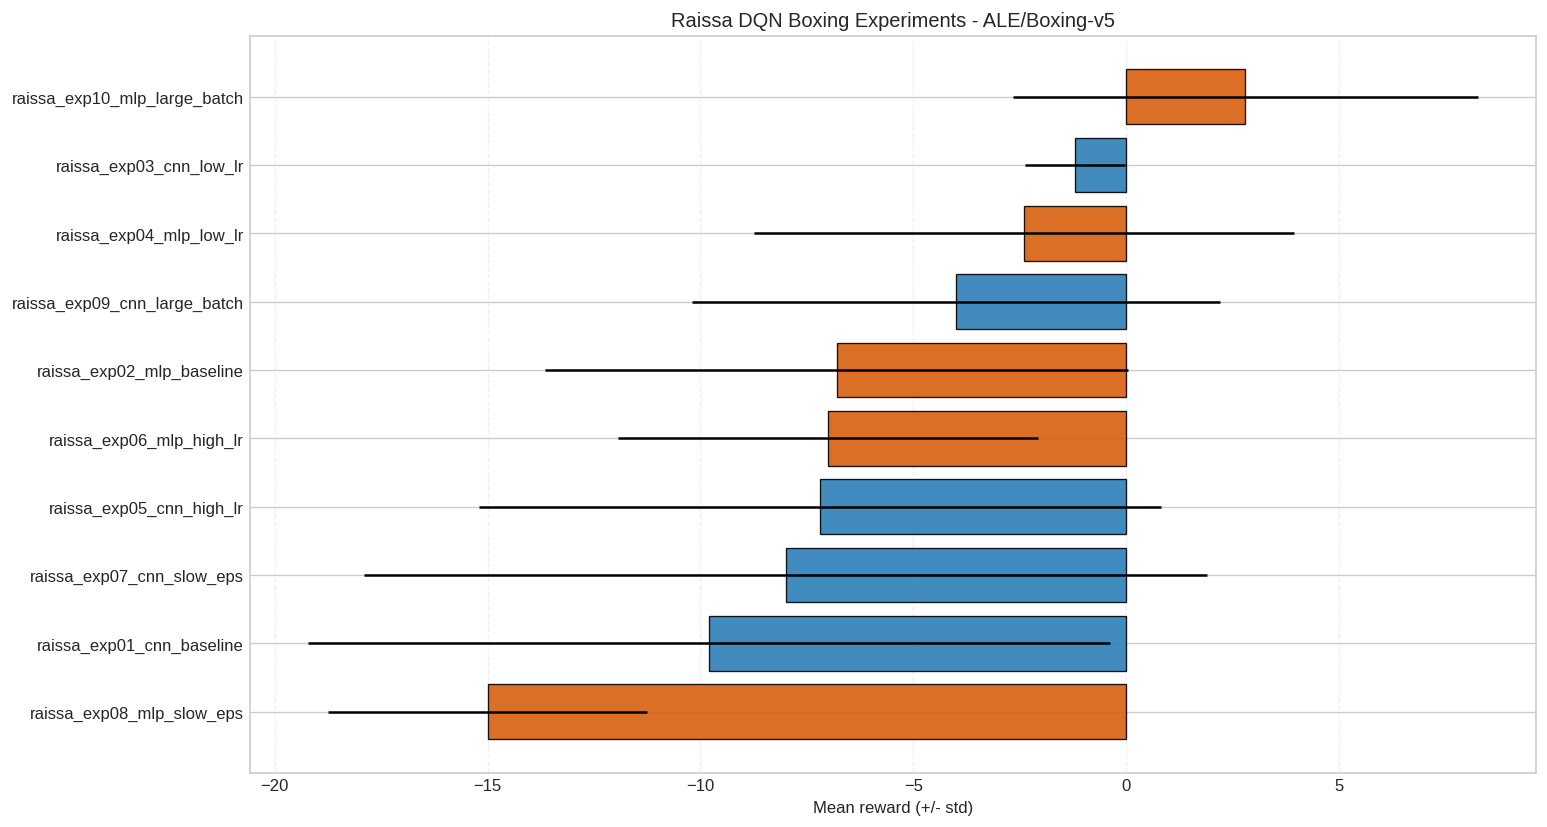

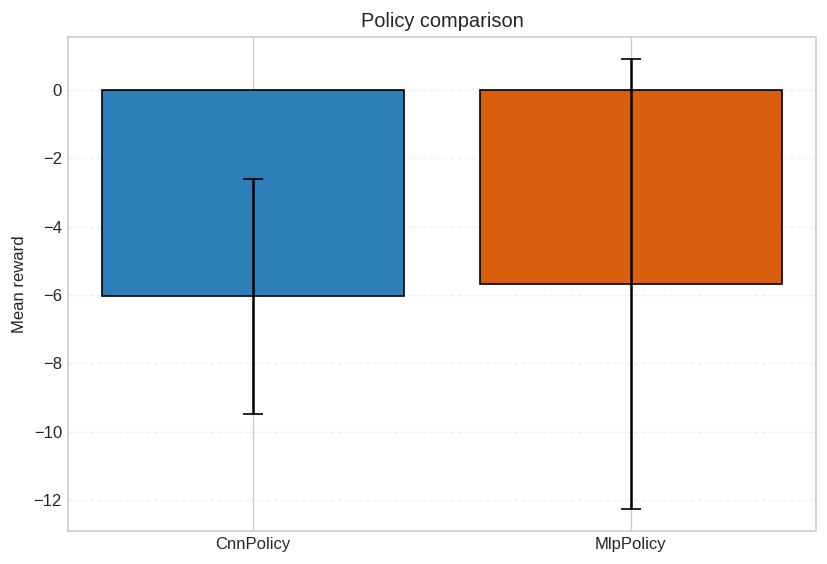

,policy,mean_reward,std_reward,count
0,CnnPolicy,-6.04,3.424617,5
1,MlpPolicy,-5.68,6.567496,5


Successful runs: 10 / 10


In [8]:
# Visualization 1: experiment ranking and policy summary (robust, standalone)
if "pd" not in globals():
    import pandas as pd
if "plt" not in globals():
    import matplotlib.pyplot as plt
if "ENV_ID" not in globals():
    ENV_ID = "ALE/Boxing-v5"

results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"

viz_df = None
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    results_df.to_csv(results_csv_path, index=False)
    viz_df = pd.read_csv(results_csv_path)
elif results_csv_path.exists():
    viz_df = pd.read_csv(results_csv_path)

if viz_df is None or viz_df.empty:
    print("No results available. Run training first.")
else:
    expected_df = pd.DataFrame([
        {"name": e["name"], "policy": e["policy"]}
        for e in EXPERIMENTS
    ])

    needed_cols = ["name", "policy", "mean_reward", "std_reward"]
    missing_cols = [c for c in needed_cols if c not in viz_df.columns]
    if missing_cols:
        print(f"Missing columns in results CSV: {missing_cols}")
    else:
        viz_df["mean_reward"] = pd.to_numeric(viz_df["mean_reward"], errors="coerce")
        viz_df["std_reward"] = pd.to_numeric(viz_df["std_reward"], errors="coerce")

        plot_df = expected_df.merge(
            viz_df[needed_cols],
            on=["name", "policy"],
            how="left",
        )
        plot_df["status"] = plot_df["mean_reward"].apply(lambda x: "ok" if pd.notna(x) else "missing")
        plot_df = plot_df.sort_values("mean_reward", ascending=True, na_position="first")

        values = plot_df["mean_reward"].fillna(0.0)
        errors = plot_df["std_reward"].fillna(0.0)

        fig, ax = plt.subplots(figsize=(13, 7))
        colors = [
            "#2c7fb8" if (p == "CnnPolicy" and s == "ok") else
            "#d95f0e" if (p == "MlpPolicy" and s == "ok") else
            "#bdbdbd"
            for p, s in zip(plot_df["policy"], plot_df["status"])
]

        ax.barh(plot_df["name"], values, xerr=errors, color=colors, alpha=0.9, edgecolor="black", linewidth=0.8)
        for y, status in zip(plot_df["name"], plot_df["status"]):
            if status != "ok":
                ax.text(0.2, y, "NOT RUN", va="center", fontsize=8, color="#666")

        ax.set_xlabel("Mean reward (+/- std)")
        ax.set_title(f"Raissa DQN Boxing Experiments - {ENV_ID}")
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # Robust summary aggregation (fixes column length mismatch).
        summary = (
            viz_df.dropna(subset=["policy"])
            .groupby("policy")["mean_reward"]
            .agg(mean_reward="mean", std_reward="std", count="count")
            .reset_index()
        )

        fig2, ax2 = plt.subplots(figsize=(7, 4.8))
        policy_colors = ["#2c7fb8" if p == "CnnPolicy" else "#d95f0e" for p in summary["policy"]]
        ax2.bar(
            summary["policy"],
            summary["mean_reward"],
            yerr=summary["std_reward"].fillna(0),
            color=policy_colors,
            edgecolor="black",
            capsize=6,
        )
        ax2.set_ylabel("Mean reward")
        ax2.set_title("Policy comparison")
        ax2.grid(axis="y", alpha=0.3, linestyle="--")
        plt.tight_layout()
        plt.show()
        plt.close(fig2)

        display(summary)
        print(f"Successful runs: {(plot_df['status'] == 'ok').sum()} / {len(plot_df)}")

In [10]:
# Export core artifacts to a single folder
if "results_df" not in globals() or results_df.empty:
    print("results_df is empty. Run training first.")
else:
    artifact_paths = [
        MODEL_DIR / "dqn_model.zip",
        MODEL_DIR / "best_dqn_boxing.zip",
        TABLE_DIR / "raissa_hyperparameter_results.csv",
        TABLE_DIR / "raissa_hyperparameter_results.md",
        TABLE_DIR / "raissa_assignment_table.csv",
    ]

    export_dir = TABLE_DIR / "exports"
    export_dir.mkdir(parents=True, exist_ok=True)

    print("Artifacts:")
    for p in artifact_paths:
        if p.exists():
            dst = export_dir / p.name
            shutil.copy(str(p), str(dst))
            print(f"OK: {p}")
        else:
            print(f"MISSING: {p}")

    # Kaggle submissions can pick artifacts from /kaggle/working and /kaggle/output.
    kaggle_output = Path("/kaggle/output")
    if kaggle_output.exists():
        kaggle_export = kaggle_output / "boxing_dqn_exports"
        kaggle_export.mkdir(parents=True, exist_ok=True)
        shutil.copytree(export_dir, kaggle_export, dirs_exist_ok=True)
        print(f"Copied artifacts to Kaggle output: {kaggle_export}")

    sync_results_to_drive("post_export")
    print(f"Export folder: {export_dir}")

Artifacts:
OK: /kaggle/working/results/Raissa/models/dqn_model.zip
OK: /kaggle/working/results/Raissa/models/best_dqn_boxing.zip
OK: /kaggle/working/results/Raissa/tables/raissa_hyperparameter_results.csv
OK: /kaggle/working/results/Raissa/tables/raissa_hyperparameter_results.md
MISSING: /kaggle/working/results/Raissa/tables/raissa_assignment_table.csv
[SYNC] Synced (post_export) -> /kaggle/working/drive_backup/boxing_dqn_agent/results/Raissa
Export folder: /kaggle/working/results/Raissa/tables/exports


## 3. Reload Results Table

In [11]:
# Rebuild report dataframe from saved CSV (or memory fallback)
results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"

if results_csv_path.exists():
    report_df = pd.read_csv(results_csv_path)
    print(f"Loaded: {results_csv_path}")
elif "results_df" in globals() and not results_df.empty:
    report_df = results_df.copy()
    print("Using in-memory results_df.")
else:
    report_df = pd.DataFrame()
    print("No saved results found.")

if not report_df.empty:
    df = pd.DataFrame({
        "Exp": report_df["name"],
        "Policy": report_df["policy"],
        "lr": report_df["learning_rate"],
        "gamma": report_df["gamma"],
        "batch": report_df["batch_size"],
        "eps_start": report_df["exploration_initial_eps"],
        "eps_end": report_df["exploration_final_eps"],
        "eps_frac": report_df["exploration_fraction"],
        "mean_reward": report_df["mean_reward"],
        "std_reward": report_df["std_reward"],
        "train_min": report_df["train_minutes"],
    }).sort_values("mean_reward", ascending=False).reset_index(drop=True)

    display(df)
else:
    df = pd.DataFrame()

Loaded: /kaggle/working/results/Raissa/tables/raissa_hyperparameter_results.csv


,Exp,Policy,lr,gamma,batch,eps_start,eps_end,eps_frac,mean_reward,std_reward,train_min
0,raissa_exp10_mlp_large_batch,MlpPolicy,0.00010,0.99,128,1.0,0.05,0.1,2.8,5.455273,1.530903
1,raissa_exp03_cnn_low_lr,CnnPolicy,0.00005,0.99,32,1.0,0.05,0.1,-1.2,1.166190,5.076562
2,raissa_exp04_mlp_low_lr,MlpPolicy,0.00005,0.99,32,1.0,0.05,0.1,-2.4,6.343501,1.552472
3,raissa_exp09_cnn_large_batch,CnnPolicy,0.00010,0.99,128,1.0,0.05,0.1,-4.0,6.196773,6.337565
4,raissa_exp02_mlp_baseline,MlpPolicy,0.00010,0.99,32,1.0,0.05,0.1,-6.8,6.852737,1.532663
5,raissa_exp06_mlp_high_lr,MlpPolicy,0.00025,0.99,32,1.0,0.05,0.1,-7.0,4.939636,1.529870
6,raissa_exp05_cnn_high_lr,CnnPolicy,0.00025,0.99,32,1.0,0.05,0.1,-7.2,8.009994,5.038763
7,raissa_exp07_cnn_slow_eps,CnnPolicy,0.00010,0.99,32,1.0,0.10,0.5,-8.0,9.899495,4.820394
8,raissa_exp01_cnn_baseline,CnnPolicy,0.00010,0.99,32,1.0,0.05,0.1,-9.8,9.410632,5.127431
9,raissa_exp08_mlp_slow_eps,MlpPolicy,0.00010,0.99,32,1.0,0.10,0.5,-15.0,3.741657,1.461212


## 4. Assignment Hyperparameter Table

In [12]:
# Build assignment-format table and merge actual performance when available

def default_behavior(exp_name: str, policy: str) -> str:
    if policy == "MlpPolicy":
        return f"{exp_name}: MLP ablation on Boxing; typically weaker than CNN on pixel observations."
    return f"{exp_name}: CNN configuration for Boxing; compare stability and final reward against baseline."

assignment_rows = []
for exp_cfg in EXPERIMENTS:
    hp = exp_cfg["hp"]
    hset = (
        f"lr={hp['learning_rate']}, gamma={hp['gamma']}, batch={hp['batch_size']}, "
        f"epsilon_start={hp['exploration_initial_eps']}, epsilon_end={hp['exploration_final_eps']}, "
        f"epsilon_decay={hp['exploration_fraction']}"
    )
    assignment_rows.append({
        "Member Name": "Raissa",
        "Experiment": exp_cfg["name"],
        "Hyperparameter Set": hset,
        "Noted Behavior": default_behavior(exp_cfg["name"], exp_cfg["policy"]),
    })

assignment_df = pd.DataFrame(assignment_rows)

if "df" in globals() and not df.empty:
    reward_map = dict(zip(df["Exp"], zip(df["mean_reward"], df["std_reward"])))
    notes = []
    for _, row in assignment_df.iterrows():
        mr, sr = reward_map.get(row["Experiment"], (None, None))
        if mr is None:
            notes.append(row["Noted Behavior"] + " Mean reward: not run yet.")
        else:
            notes.append(row["Noted Behavior"] + f" Mean reward: {mr:.2f} +/- {sr:.2f}.")
    assignment_df["Noted Behavior"] = notes

display(assignment_df[["Member Name", "Experiment", "Hyperparameter Set", "Noted Behavior"]])

assignment_table_path = TABLE_DIR / "raissa_assignment_table.csv"
assignment_df.to_csv(assignment_table_path, index=False)
print(f"Saved: {assignment_table_path}")

,Member Name,Experiment,Hyperparameter Set,Noted Behavior
0,Raissa,raissa_exp01_cnn_baseline,"lr=0.0001, gamma=0.99, batch=32, epsilon_start...",raissa_exp01_cnn_baseline: CNN configuration f...
1,Raissa,raissa_exp02_mlp_baseline,"lr=0.0001, gamma=0.99, batch=32, epsilon_start...",raissa_exp02_mlp_baseline: MLP ablation on Box...
2,Raissa,raissa_exp03_cnn_low_lr,"lr=5e-05, gamma=0.99, batch=32, epsilon_start=...",raissa_exp03_cnn_low_lr: CNN configuration for...
3,Raissa,raissa_exp04_mlp_low_lr,"lr=5e-05, gamma=0.99, batch=32, epsilon_start=...",raissa_exp04_mlp_low_lr: MLP ablation on Boxin...
4,Raissa,raissa_exp05_cnn_high_lr,"lr=0.00025, gamma=0.99, batch=32, epsilon_star...",raissa_exp05_cnn_high_lr: CNN configuration fo...
5,Raissa,raissa_exp06_mlp_high_lr,"lr=0.00025, gamma=0.99, batch=32, epsilon_star...",raissa_exp06_mlp_high_lr: MLP ablation on Boxi...
6,Raissa,raissa_exp07_cnn_slow_eps,"lr=0.0001, gamma=0.99, batch=32, epsilon_start...",raissa_exp07_cnn_slow_eps: CNN configuration f...
7,Raissa,raissa_exp08_mlp_slow_eps,"lr=0.0001, gamma=0.99, batch=32, epsilon_start...",raissa_exp08_mlp_slow_eps: MLP ablation on Box...
8,Raissa,raissa_exp09_cnn_large_batch,"lr=0.0001, gamma=0.99, batch=128, epsilon_star...",raissa_exp09_cnn_large_batch: CNN configuratio...
9,Raissa,raissa_exp10_mlp_large_batch,"lr=0.0001, gamma=0.99, batch=128, epsilon_star...",raissa_exp10_mlp_large_batch: MLP ablation on ...


Saved: /kaggle/working/results/Raissa/tables/raissa_assignment_table.csv


## 5. Reward Comparison Chart

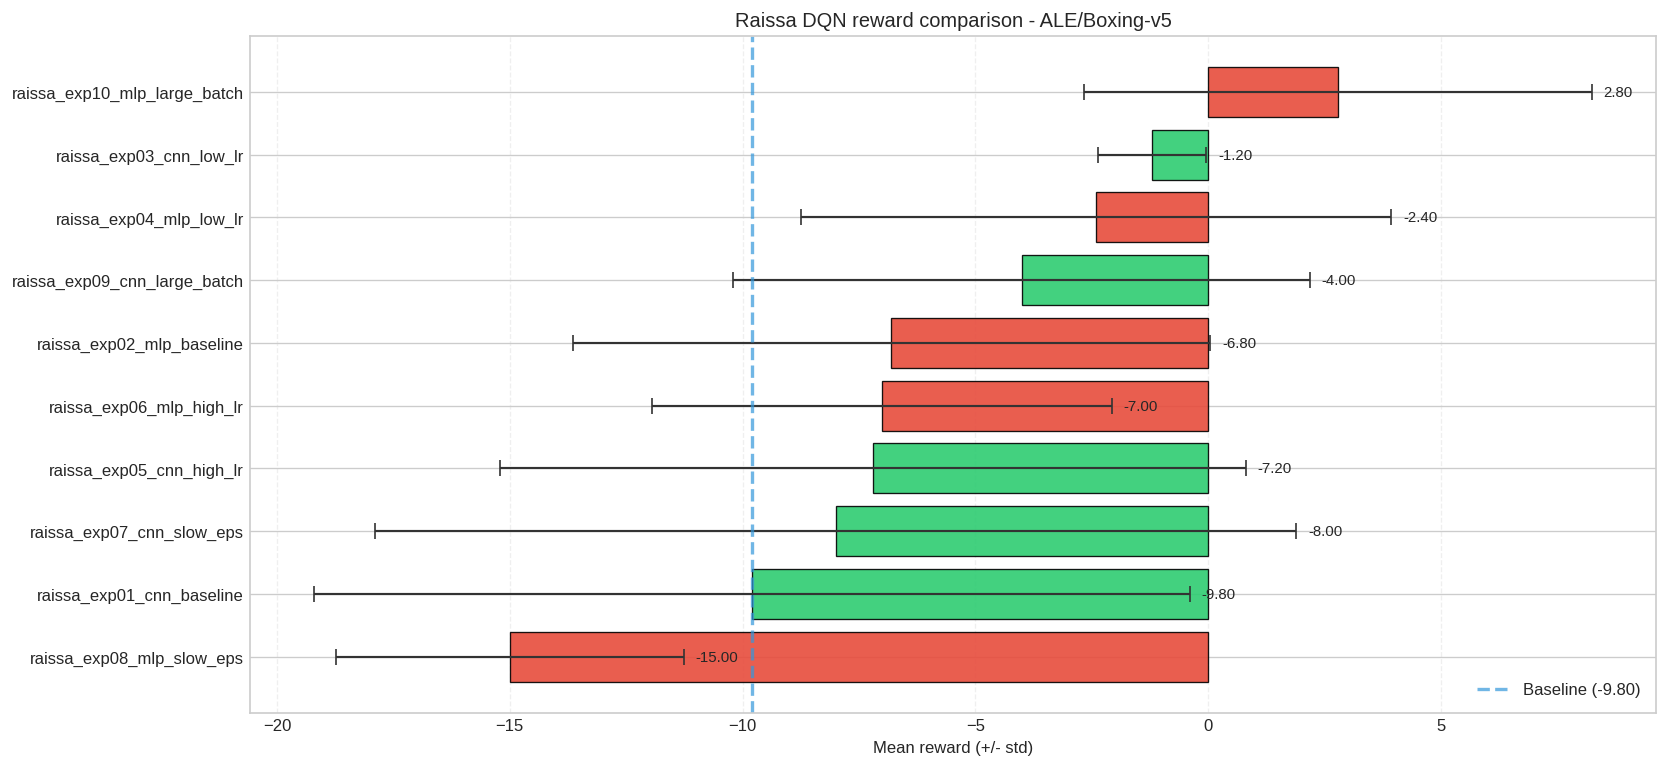

Successful runs: 10 / 10


In [13]:
# Reward comparison chart
results_csv_path = TABLE_DIR / "raissa_hyperparameter_results.csv"

plot_df = None
if "df" in globals() and isinstance(df, pd.DataFrame) and len(df) > 0:
    plot_df = df.copy()
elif results_csv_path.exists():
    rep = pd.read_csv(results_csv_path)
    plot_df = pd.DataFrame({
        "Exp": rep["name"],
        "Policy": rep["policy"],
        "mean_reward": rep["mean_reward"],
        "std_reward": rep["std_reward"],
    })

if plot_df is None or plot_df.empty:
    print("No results yet. Run training first.")
else:
    expected = pd.DataFrame([{"Exp": e["name"], "Policy": e["policy"]} for e in EXPERIMENTS])
    plot_df = expected.merge(plot_df, on=["Exp", "Policy"], how="left")
    plot_df["status"] = plot_df["mean_reward"].apply(lambda x: "ok" if pd.notna(x) else "missing")
    plot_df = plot_df.sort_values("mean_reward", ascending=False, na_position="last").reset_index(drop=True)

    y = plot_df["mean_reward"].fillna(0.0)
    yerr = plot_df["std_reward"].fillna(0.0)

    fig, ax = plt.subplots(figsize=(14, 6.5))
    colors = [
        "#2ecc71" if ("Cnn" in p and s == "ok") else
        "#e74c3c" if ("Mlp" in p and s == "ok") else
        "#95a5a6"
        for p, s in zip(plot_df["Policy"], plot_df["status"])
    ]

    bars = ax.barh(
        plot_df["Exp"],
        y,
        xerr=yerr,
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.9,
        error_kw=dict(ecolor="#333", capsize=5, lw=1.3),
    )

    for bar, val, std, status in zip(bars, y, yerr, plot_df["status"]):
        if status == "ok":
            ax.text(bar.get_width() + std + 0.25, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
        else:
            ax.text(0.4, bar.get_y() + bar.get_height() / 2, "NOT RUN", va="center", fontsize=8, color="#666")

    baseline = plot_df[plot_df["Exp"] == "raissa_exp01_cnn_baseline"]
    if not baseline.empty and baseline.iloc[0]["status"] == "ok":
        b = baseline.iloc[0]["mean_reward"]
        ax.axvline(b, color="#3498db", ls="--", lw=2, alpha=0.7, label=f"Baseline ({b:.2f})")

    ax.set_xlabel("Mean reward (+/- std)")
    ax.set_title(f"Raissa DQN reward comparison - {ENV_ID}")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    print(f"Successful runs: {(plot_df['status'] == 'ok').sum()} / {len(plot_df)}")

## 6. Save Best Model as dqn_model.zip

In [27]:
# Save the best model as dqn_model.zip
if "df" in globals() and len(df) > 0:
    best_row = df.loc[df["mean_reward"].idxmax()]
    best_exp = best_row["Exp"]
    print(f"Best experiment: {best_exp}")
    print(f"Mean reward: {best_row['mean_reward']:.2f}")

    src = MODEL_DIR / f"{best_exp}.zip"
    alt = MODEL_DIR / "best_dqn_boxing.zip"
    target = MODEL_DIR / "dqn_model.zip"

    if src.exists():
        shutil.copy(str(src), str(target))
        print(f"Saved: {target}")
    elif alt.exists():
        shutil.copy(str(alt), str(target))
        print(f"Saved fallback best: {target}")
    else:
        print("Model zip not found. Run training first.")
else:
    print("No results. Run training and reload results first.")

Best experiment: raissa_exp10_mlp_large_batch
Mean reward: 2.80
Saved: /kaggle/working/results/Raissa/models/dqn_model.zip


## 7. Key Insights Summary

In [15]:
# Print concise performance insights
if "df" in globals() and len(df) > 0:
    best = df.loc[df["mean_reward"].idxmax()]
    worst = df.loc[df["mean_reward"].idxmin()]

    cnn_rows = df[df["Policy"] == "CnnPolicy"]
    mlp_rows = df[df["Policy"] == "MlpPolicy"]
    cnn_mean = float(cnn_rows["mean_reward"].mean()) if not cnn_rows.empty else float("nan")
    mlp_mean = float(mlp_rows["mean_reward"].mean()) if not mlp_rows.empty else float("nan")

    print("=" * 68)
    print(f"KEY INSIGHTS - {MEMBER} - {ENV_ID}")
    print("=" * 68)
    print(f"Best config  : {best['Exp']} | reward={best['mean_reward']:.2f} +/- {best['std_reward']:.2f}")
    print(f"Worst config : {worst['Exp']} | reward={worst['mean_reward']:.2f} +/- {worst['std_reward']:.2f}")
    print(f"CNN average  : {cnn_mean:.2f}")
    print(f"MLP average  : {mlp_mean:.2f}")

    if pd.notna(cnn_mean) and pd.notna(mlp_mean):
        better = "CNN" if cnn_mean > mlp_mean else "MLP"
        print(f"Better policy family: {better} by {abs(cnn_mean - mlp_mean):.2f} points")

    print("Recommendation: prioritize the top 2 CNN configs, then rerun with 200k timesteps for stronger mean reward estimates.")
    print("=" * 68)
else:
    print("No results found. Run training first.")

KEY INSIGHTS - Raissa - ALE/Boxing-v5
Best config  : raissa_exp10_mlp_large_batch | reward=2.80 +/- 5.46
Worst config : raissa_exp08_mlp_slow_eps | reward=-15.00 +/- 3.74
CNN average  : -6.04
MLP average  : -5.68
Better policy family: MLP by 0.36 points
Recommendation: prioritize the top 2 CNN configs, then rerun with 200k timesteps for stronger mean reward estimates.


In [26]:
# Kaggle-friendly final packaging (replaces Colab files.download)
import zipfile

final_zip = TABLE_DIR / "raissa_kaggle_bundle.zip"
paths_to_bundle = [
    TABLE_DIR / "raissa_assignment_table.csv",
    TABLE_DIR / "raissa_hyperparameter_results.csv",
    TABLE_DIR / "raissa_hyperparameter_results.md",
    MODEL_DIR / "dqn_model.zip",
    MODEL_DIR / "best_dqn_boxing.zip",
]

with zipfile.ZipFile(final_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in paths_to_bundle:
        if p.exists():
            zf.write(p, arcname=p.relative_to(BASE_DIR))

print(f"Bundle ready: {final_zip}")

kaggle_output = Path("/kaggle/output")
if kaggle_output.exists():
    out_zip = kaggle_output / final_zip.name
    shutil.copy(str(final_zip), str(out_zip))
    print(f"Copied bundle to: {out_zip}")

sync_results_to_drive("final_bundle")

Bundle ready: /kaggle/working/results/Raissa/tables/raissa_kaggle_bundle.zip
[SYNC] Synced (final_bundle) -> /kaggle/working/drive_backup/boxing_dqn_agent/results/Raissa


In [24]:
# Verification: confirm best model, results tables, and training curves/logs are saved
from pathlib import Path

results_csv = TABLE_DIR / "raissa_hyperparameter_results.csv"
assignment_csv = TABLE_DIR / "raissa_assignment_table.csv"
best_model = MODEL_DIR / "best_dqn_boxing.zip"
assignment_model = MODEL_DIR / "dqn_model.zip"

checks = {
    "results_csv": results_csv,
    "assignment_csv": assignment_csv,
    "best_model": best_model,
    "assignment_model": assignment_model,
}

print("Save checks:")
for name, path in checks.items():
    print(f"- {name}: {'OK' if path.exists() else 'MISSING'} -> {path}")

if results_csv.exists():
    vdf = pd.read_csv(results_csv)
    if not vdf.empty and {"name", "mean_reward"}.issubset(vdf.columns):
        vdf["mean_reward"] = pd.to_numeric(vdf["mean_reward"], errors="coerce")
        vdf = vdf.sort_values("mean_reward", ascending=False)
        top = vdf.iloc[0]
        print("\nBest experiment from results table:")
        print(f"- name={top.get('name')} | policy={top.get('policy')} | mean_reward={top.get('mean_reward'):.3f}")

curve_files = sorted(LOG_DIR.glob("*_training_metrics.csv"))
print(f"\nTraining curve files found: {len(curve_files)}")
if curve_files:
    print("Sample curve file:", curve_files[0])

print("\nIf all required items show OK, artifacts are saved and ready.")

Save checks:
- results_csv: OK -> /kaggle/working/results/Raissa/tables/raissa_hyperparameter_results.csv
- assignment_csv: OK -> /kaggle/working/results/Raissa/tables/raissa_assignment_table.csv
- best_model: OK -> /kaggle/working/results/Raissa/models/best_dqn_boxing.zip
- assignment_model: OK -> /kaggle/working/results/Raissa/models/dqn_model.zip

Best experiment from results table:
- name=raissa_exp10_mlp_large_batch | policy=MlpPolicy | mean_reward=2.800

Training curve files found: 0

If all required items show OK, artifacts are saved and ready.
